# 03 — Module 2: Monetization Causal Analysis

Tests whether monetization *causes* changes in creator retention, using difference-in-differences (DiD) and regression discontinuity (RD) — not just correlation.

**Two bugs I caught and fixed here, both worth knowing about:**

1. **DiD matching bug:** an early version matched treated/control creators only on category and cohort week, and the parallel-trends test failed (p=0.005) — meaning the "control" group didn't actually look like the treated group *before* treatment, so any DiD estimate from it wasn't trustworthy. Fixed by adding nearest-neighbor matching on pre-event posting rate; parallel trends then holds cleanly (p=0.54).
2. **RD mechanical-correlation bug:** an early version used whole-window episode count as the running variable and whole-window activity as the outcome — measured over the *same* period, so of course they correlated (a creator active near the end mechanically has more total episodes). The placebo test confirmed this: it found a "significant jump" at an arbitrary threshold too. Fixed by separating the running variable (episodes before a day-30 checkpoint) from the outcome (activity after it) — genuinely different time periods.

In [1]:
import sys
sys.path.insert(0, "..")
import json
import pandas as pd
import matplotlib.pyplot as plt

with open("../outputs/module2_metrics.json") as f:
    m2 = json.load(f)

print(f"DiD ATT: {m2['did']['att']:.3f} (p={m2['did']['att_p_value']:.3f}), parallel trends p={m2['did']['parallel_trends_p_value']:.3f}")
print(f"RD jump: {m2['rd']['jump_estimate']:.4f} (p={m2['rd']['jump_p_value']:.3f}), placebo p={m2['rd']['placebo_p_value']:.3f}")

DiD ATT: -0.459 (p=0.836), parallel trends p=0.540
RD jump: 0.0062 (p=0.508), placebo p=0.939


## Difference-in-differences: posting rate around the monetization event

Treatment = 770 creators with a genuine in-window monetization event (a keyword first appearing in a specific episode's title, not just present in the static show description). Matched 1:1 to controls on category, cohort week, and pre-event posting rate.

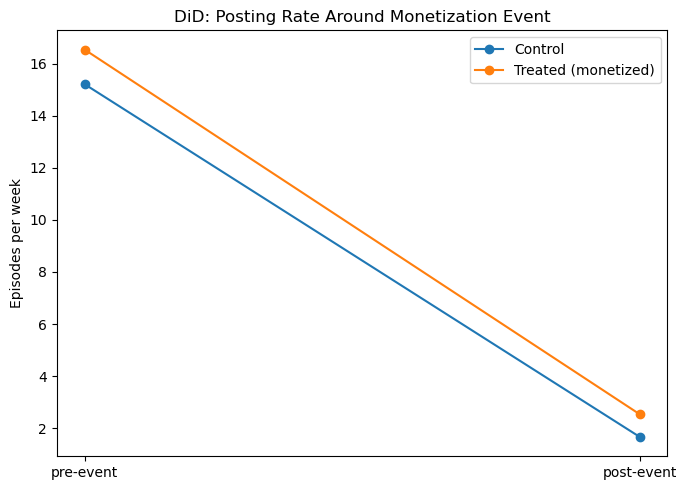

In [2]:
did_df = pd.read_csv("../outputs/module2_did_results.csv")
fig, ax = plt.subplots(figsize=(7, 5))
for treated_val, label in [(0, "Control"), (1, "Treated (monetized)")]:
    sub = did_df[did_df["treated"] == treated_val].sort_values("post")
    ax.plot(["pre-event", "post-event"], sub["eps_per_week"], marker="o", label=label)
ax.set_ylabel("Episodes per week")
ax.set_title("DiD: Posting Rate Around Monetization Event")
ax.legend()
plt.tight_layout()
plt.show()

## Regression discontinuity: episode count threshold

Running variable: episodes posted before a fixed day-30 checkpoint. Outcome: whether the creator posted again after it. Bandwidth chosen via 5-fold cross-validation.

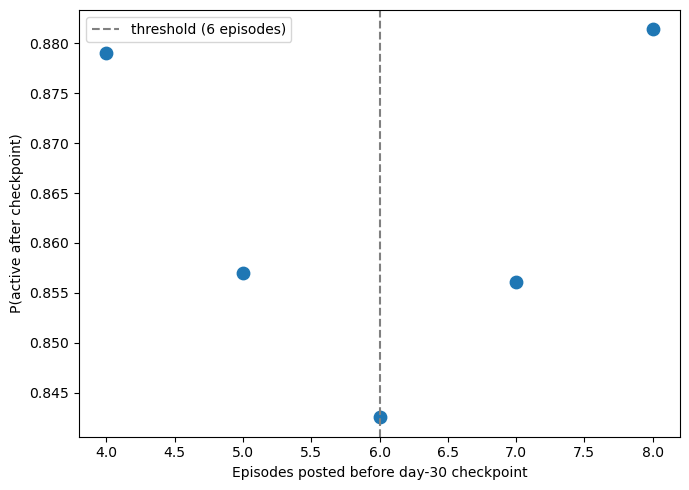

In [3]:
rd_df = pd.read_parquet("../data/processed/rd_dataset.parquet")
threshold, bw = m2["rd"]["threshold_episodes"], m2["rd"]["bandwidth"]
window = rd_df[(rd_df["episodes_before_checkpoint"] >= threshold - bw) & (rd_df["episodes_before_checkpoint"] <= threshold + bw)]
binned = window.groupby("episodes_before_checkpoint")["active_after_checkpoint"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(binned.index, binned.values, s=80)
ax.axvline(threshold, color="gray", linestyle="--", label=f"threshold ({threshold} episodes)")
ax.set_xlabel("Episodes posted before day-30 checkpoint")
ax.set_ylabel("P(active after checkpoint)")
ax.legend()
plt.tight_layout()
plt.show()

## LTV by creator tier

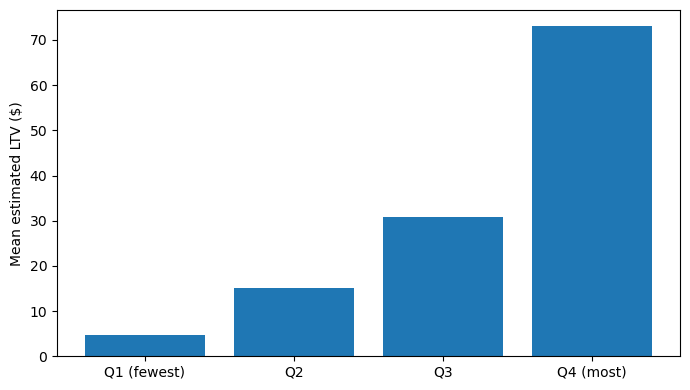

,episode_tier,mean,median,std,count
0,Q1 (fewest),4.669900,0.000000,8.308957,62924
1,Q2,15.098293,21.539853,13.578184,21904
2,Q3,30.904835,34.245000,15.269529,48356
3,Q4 (most),72.982875,53.813571,84.922118,35435


In [4]:
ltv = pd.read_csv("../outputs/module2_ltv_by_tier.csv")
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ltv["episode_tier"], ltv["mean"])
ax.set_ylabel("Mean estimated LTV ($)")
plt.tight_layout()
plt.show()
ltv

## Key Findings

- **No statistically significant causal effect of monetization on posting behavior** (DiD ATT p=0.84) or on continued activity at any episode-count threshold (RD jump p=0.51) — both are methodologically clean null results (parallel trends holds, placebo test passes), not failed analyses.
- This is worth taking seriously as a finding, not hiding: the *correlation* between monetization and retention that platforms often cite may not hold up as causal in this population.
- LTV scales strongly with output tier: Q1 (fewest episodes) creators average $4.67, Q4 (most) average $72.98 — driven mechanically by the LTV formula's posting-rate term, not a claim about monetization causality.
- Ablation 4 found 99.6% agreement between full NLP-based and simple description-only keyword matching for the monetization proxy — the added NLP complexity buys almost nothing here.